In [35]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
import calendar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/analogues')   # alice

import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [36]:
# Upload ERA5 files in present working directory
dir = '/home/alice/Desktop/work/git/myISACcode/python/analogues/analogue_data/psl_min'
# Define events
list_nodes = [1,3,5,6]
list_events = [1,3,4,19]
# Define analogue variables
list_varstr = ['mslp','mslp-std','mslp-z500-std']
# Define minima names
list_min = ['min-mslp', 'min-from-boxmean-mslp']
# Define no analogues
n_analogues = 18

# Upload all files
pmin_values = np.ones((len(list_nodes), len(list_varstr), len(list_min), n_analogues)) * np.nan
for i, (no_node, no_event) in enumerate(zip(list_nodes, list_events)):
    for j, var_str in enumerate(list_varstr):
        for k, min_str in enumerate(list_min):
            filename = f'analogues-{var_str}_{min_str}_node{list_nodes[i]}-extreme{list_events[i]}-alertregions_99pct_2004-2023_ERA5.nc'
            ds = xr.open_dataset(os.path.join(dir, filename))
            pmin_values[i, j, k] = ds['msl'].values

/tmp/ipykernel_58249/591081476.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


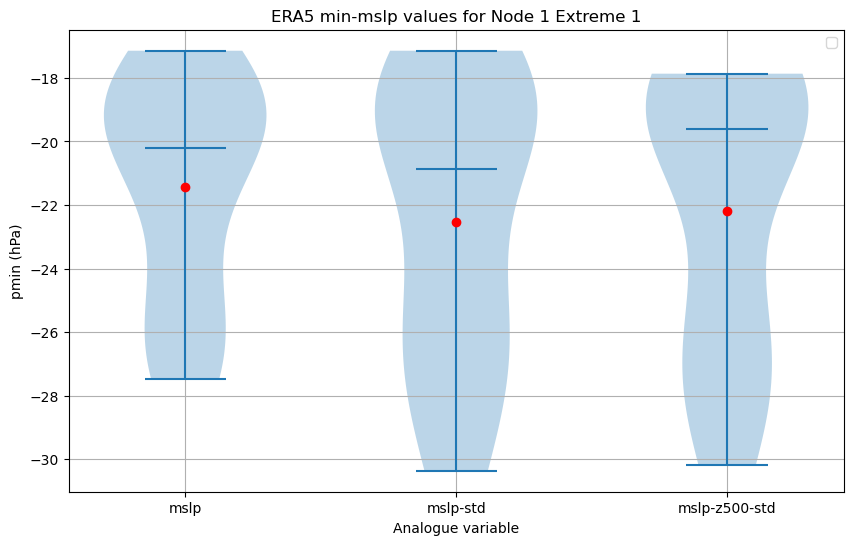

/tmp/ipykernel_58249/591081476.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


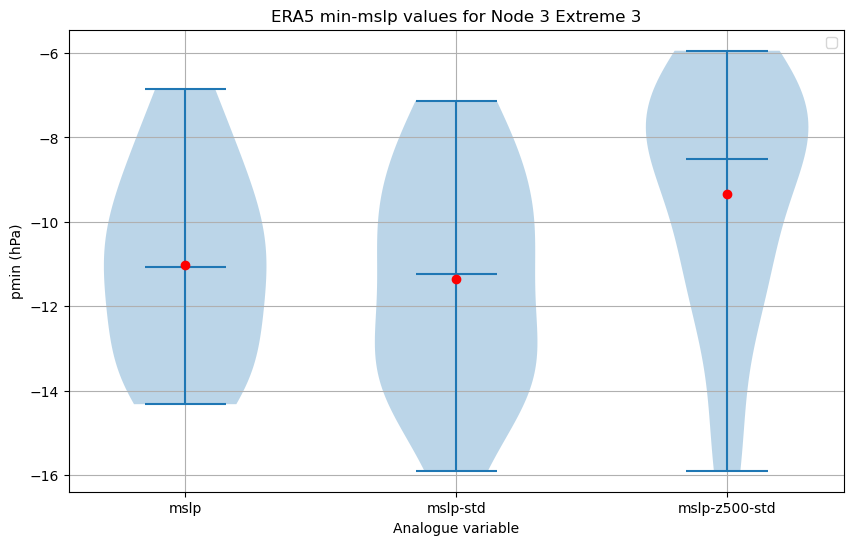

/tmp/ipykernel_58249/591081476.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


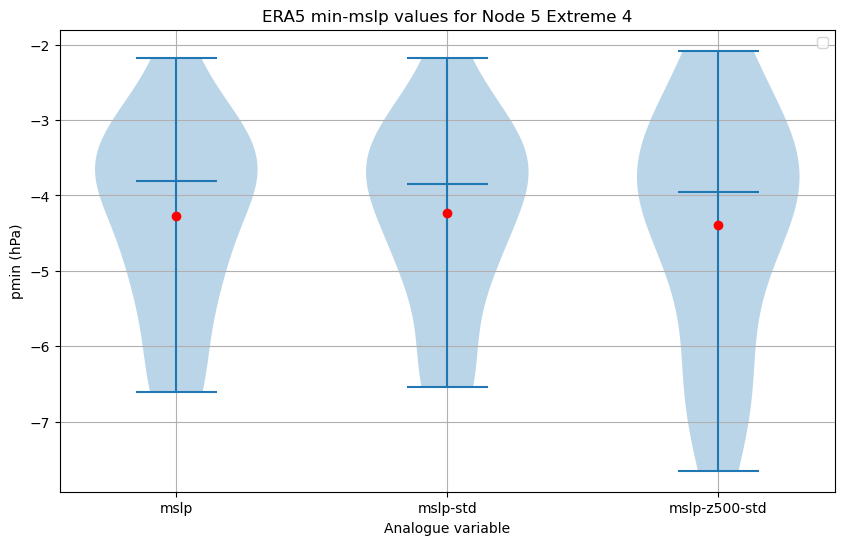

/tmp/ipykernel_58249/591081476.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


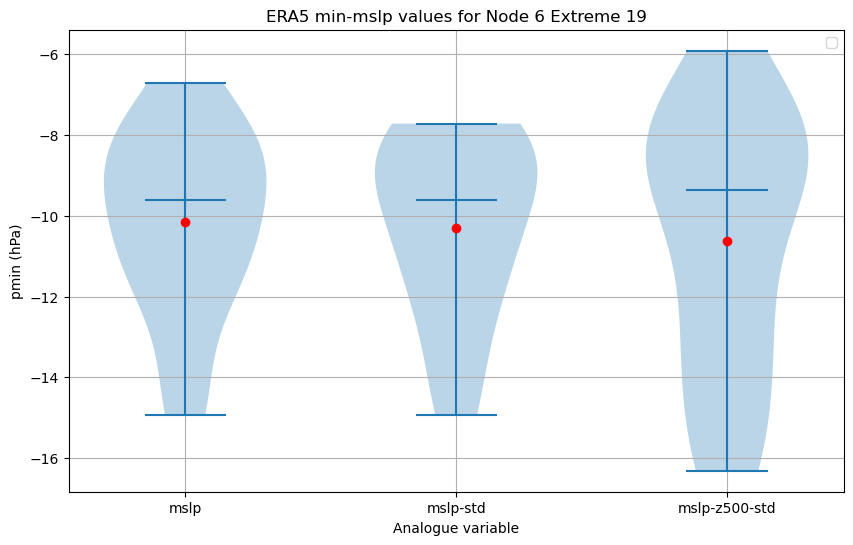

In [40]:
# For every event, plot pmin values in violin plot for different variables and minima types
type_min = 0  # 0 for 'min-mslp', 1 for 'min-from-boxmean-mslp'
for i, (no_node, no_event) in enumerate(zip(list_nodes, list_events)):
    plt.figure(figsize=(10,6))
    min_str = list_min[type_min]
    list_pmin = [pmin_values[i, j,type_min] for j in range(len(list_varstr))]
    plt.violinplot(list_pmin, positions=np.arange(len(list_varstr)), widths=0.6, showmedians=True, showextrema=True)
    means = [np.mean(d) for d in list_pmin]
    plt.scatter(range(0, len(means)), means, color="red", zorder=3)
    plt.title(f'ERA5 {min_str} values for Node {no_node} Extreme {no_event}')
    plt.xlabel('Analogue variable')
    plt.ylabel('pmin (hPa)')
    plt.xticks(np.arange(len(list_varstr)), list_varstr)
    plt.legend()
    plt.grid()
    plt.savefig(f'analogues_{min_str}_node{list_nodes[i]}-extreme{list_events[i]}-alertregions_99pct_2004-2023_ERA5.png')
    plt.show()
